# XOR: a 2 → 2 → 1 neural network from scratch

## Goal
Learn how a tiny multilayer perceptron (MLP) learns **exclusive OR**: output 1 when the two binary inputs differ, and 0 when they match. Implement every learning step using **Python and NumPy**, then visualize the nonlinear decision region with Matplotlib. No machine-learning framework or automatic differentiation is used.

The four points are the complete XOR truth table. This is a learning demonstration, not a train/test generalization experiment. Predictions between these points illustrate the model's learned extension; XOR itself is defined here only on binary inputs.

## Setup
Open this notebook in JupyterLab, Jupyter Notebook, or Google Colab and **Run All** from a fresh kernel. Saved outputs are included. If needed, uncomment the installation command below. The optional slider requires `ipywidgets` and a live kernel; all main results work without it.

In [1]:
# Uncomment only if your environment needs these packages:
# %pip install numpy matplotlib
# Optional training replay:
# %pip install ipywidgets

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Markdown

plt.rcParams.update({"figure.figsize": (6.5, 5), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
COLORS = {0: "#2369A0", 1: "#D77A16"}
PROB_CMAP = LinearSegmentedColormap.from_list("xor", ["#DCEBF6", "#FFF0D6"])
SEED = 7
LEARNING_RATE = 0.1
EPOCHS = 10000
SNAPSHOT_EVERY = 100
print(f"NumPy {np.__version__}; seed={SEED}; learning rate={LEARNING_RATE}; epochs={EPOCHS}")

Matplotlib is building the font cache; this may take a moment.


NumPy 2.3.5; seed=7; learning rate=0.1; epochs=10000


## Steps
### 1. Meet the four XOR points
No single straight line can separate the two classes. The hidden layer introduces a nonlinear transformation that makes the task possible.

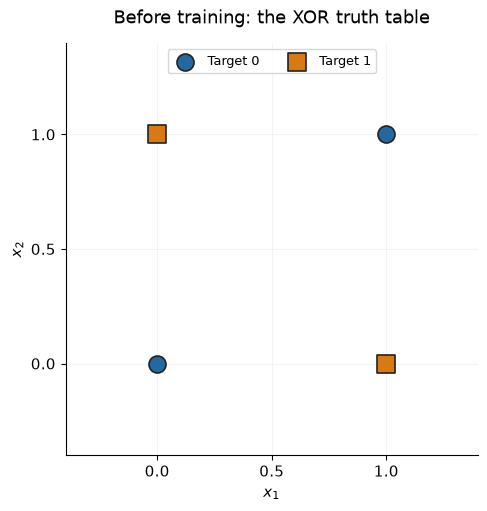

In [2]:
X = np.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])  # (4, 2)
y = np.array([[0.], [1.], [1.], [0.]])                      # (4, 1)

def draw_points(ax):
    for label, marker in [(0, "o"), (1, "s")]:
        rows = y[:, 0] == label
        ax.scatter(X[rows, 0], X[rows, 1], c=COLORS[label], marker=marker,
                   s=150, edgecolors="#222222", linewidths=1.2,
                   label=f"Target {label}", zorder=3)
    ax.set(xlabel="$x_1$", ylabel="$x_2$", xlim=(-0.4, 1.4), ylim=(-0.4, 1.4))
    ax.set_aspect("equal")
    ax.set_xticks([0, 0.5, 1]); ax.set_yticks([0, 0.5, 1])
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=2, fontsize=9)

fig, ax = plt.subplots(layout="constrained")
draw_points(ax)
ax.set_title("Before training: the XOR truth table", pad=14)
ax.grid(alpha=0.15)
plt.show()

### 2. Forward propagation and binary cross-entropy
Rows are examples. The network has **9 trainable parameters**: 4 + 2 weights and 2 + 1 biases.

| Quantity | Shape | Meaning |
|---|---|---|
| $X$ | $(N,2)$ | Input batch |
| $W_1, b_1$ | $(2,2), (1,2)$ | Hidden-layer weights and biases |
| $H$ | $(N,2)$ | Two hidden activations |
| $W_2, b_2$ | $(2,1), (1,1)$ | Output-layer weights and bias |
| $p$ | $(N,1)$ | Predicted probability of class 1 |

$$Z_1=XW_1+b_1,\qquad H=\tanh(Z_1)$$
$$Z_2=HW_2+b_2,\qquad p=\sigma(Z_2)=\frac{1}{1+e^{-Z_2}}$$
$$L=-\frac1N\sum_i\left[y_i\log p_i+(1-y_i)\log(1-p_i)\right]$$

The code computes the equivalent, numerically stable **BCE from logits**:
$L=\operatorname{mean}(\log(1+e^{Z_2})-yZ_2)$ using `np.logaddexp`.
Random weights break symmetry so the hidden neurons can learn different features.

In [3]:
def initialize(seed=SEED):
    rng = np.random.default_rng(seed)
    return {"W1": rng.normal(0, 1, (2, 2)) / np.sqrt(2),
            "b1": np.zeros((1, 2)),
            "W2": rng.normal(0, 1, (2, 1)) / np.sqrt(2),
            "b2": np.zeros((1, 1))}

def sigmoid(z):
    return np.exp(-np.logaddexp(0, -z))  # stable even for large |z|

def forward(inputs, params):
    hidden = np.tanh(inputs @ params["W1"] + params["b1"])
    logits = hidden @ params["W2"] + params["b2"]
    probabilities = sigmoid(logits)
    return probabilities, (hidden, logits)

def bce_loss(logits, targets):
    return np.mean(np.logaddexp(0, logits) - targets * logits)

initial_params = initialize()
initial_p, (_, initial_logits) = forward(X, initial_params)
print(f"Initial BCE: {bce_loss(initial_logits, y):.6f}")

Initial BCE: 0.707763


### 3. Backpropagation: apply the chain rule
For sigmoid combined with BCE, the output-logit derivative simplifies to:

$$D_2=\frac{p-y}{N},\quad \nabla_{W_2}L=H^T D_2,\quad \nabla_{b_2}L=\sum_i D_{2,i}$$
$$D_1=(D_2 W_2^T)\odot(1-H^2),\quad \nabla_{W_1}L=X^T D_1,\quad \nabla_{b_1}L=\sum_i D_{1,i}$$

Here $\odot$ is elementwise multiplication, and $1-H^2$ is the derivative of tanh. The batch average is included **once**, in $D_2$. Compute all gradients before changing any parameters.

In [4]:
def backward(inputs, targets, params, probabilities, cache):
    hidden, _ = cache
    d_logits = (probabilities - targets) / len(inputs)
    d_hidden_logits = (d_logits @ params["W2"].T) * (1 - hidden**2)
    return {"W1": inputs.T @ d_hidden_logits,
            "b1": d_hidden_logits.sum(axis=0, keepdims=True),
            "W2": hidden.T @ d_logits,
            "b2": d_logits.sum(axis=0, keepdims=True)}

# Check all nine analytical derivatives against central finite differences.
check_params = {k: v.copy() for k, v in initial_params.items()}
p, cache = forward(X, check_params)
analytical = backward(X, y, check_params, p, cache)
epsilon = 1e-5
errors = []
for name, values in check_params.items():
    for index in np.ndindex(values.shape):
        original = values[index]
        values[index] = original + epsilon
        plus = bce_loss(forward(X, check_params)[1][1], y)
        values[index] = original - epsilon
        minus = bce_loss(forward(X, check_params)[1][1], y)
        values[index] = original
        numerical = (plus - minus) / (2 * epsilon)
        errors.append(abs(numerical - analytical[name][index]))
assert max(errors) < 1e-7
print(f"Gradient check passed. Maximum absolute error: {max(errors):.2e}")

Gradient check passed. Maximum absolute error: 9.18e-12


### 4. Train with full-batch gradient descent
Each epoch uses all four examples. Update every parameter by
$\theta\leftarrow\theta-\eta\nabla_\theta L$, with learning rate $\eta=0.1$.

Epoch 0 means **no updates**; epoch 10,000 means 10,000 completed updates. Loss and accuracy below are evaluated at that epoch's parameters. Re-running this cell starts from the same initialization.

Epoch     0 | BCE 0.707763 | accuracy 25%
Epoch  2000 | BCE 0.038205 | accuracy 100%
Epoch  4000 | BCE 0.011272 | accuracy 100%
Epoch  6000 | BCE 0.006541 | accuracy 100%
Epoch  8000 | BCE 0.004596 | accuracy 100%
Epoch 10000 | BCE 0.003538 | accuracy 100%


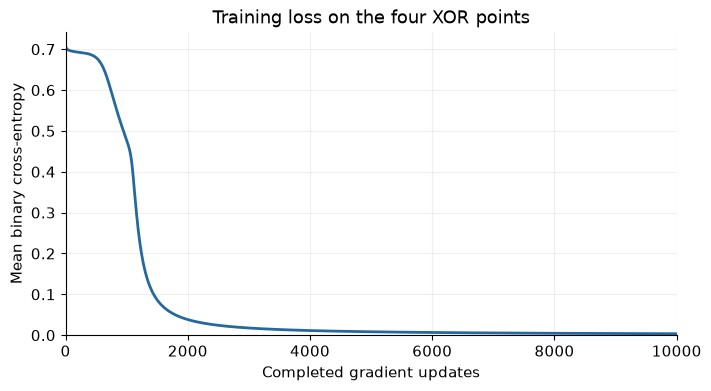

In [5]:
params = {k: v.copy() for k, v in initial_params.items()}
loss_history, accuracy_history, snapshots = [], [], []
for epoch in range(EPOCHS + 1):
    p, cache = forward(X, params)
    loss = float(bce_loss(cache[1], y))
    accuracy = float(np.mean((p >= 0.5) == y))
    loss_history.append(loss)
    accuracy_history.append(accuracy)
    if epoch % SNAPSHOT_EVERY == 0 or epoch == EPOCHS:
        snapshots.append((epoch, {k: v.copy() for k, v in params.items()}))
    if epoch % 2000 == 0 or epoch == EPOCHS:
        print(f"Epoch {epoch:5d} | BCE {loss:.6f} | accuracy {accuracy:.0%}")
    if epoch == EPOCHS:
        break
    gradients = backward(X, y, params, p, cache)
    for name in params:
        params[name] -= LEARNING_RATE * gradients[name]

fig, ax = plt.subplots(figsize=(7, 3.8), layout="constrained")
ax.plot(loss_history, color=COLORS[0], linewidth=2)
ax.set(title="Training loss on the four XOR points", xlabel="Completed gradient updates",
       ylabel="Mean binary cross-entropy", xlim=(0, EPOCHS), ylim=(0, None))
ax.grid(alpha=0.2)
plt.show()

### 5. Visualize the learned decision region
Background shading shows $P(y=1)$ over a grid. The dashed line is the **0.5 decision boundary**; circles and squares show the true labels. Both panels use identical axes and a fixed probability scale.

The boundary is nonlinear in the original input space. Its behavior away from the four observed points is an effect of this model and initialization, not additional ground-truth data.

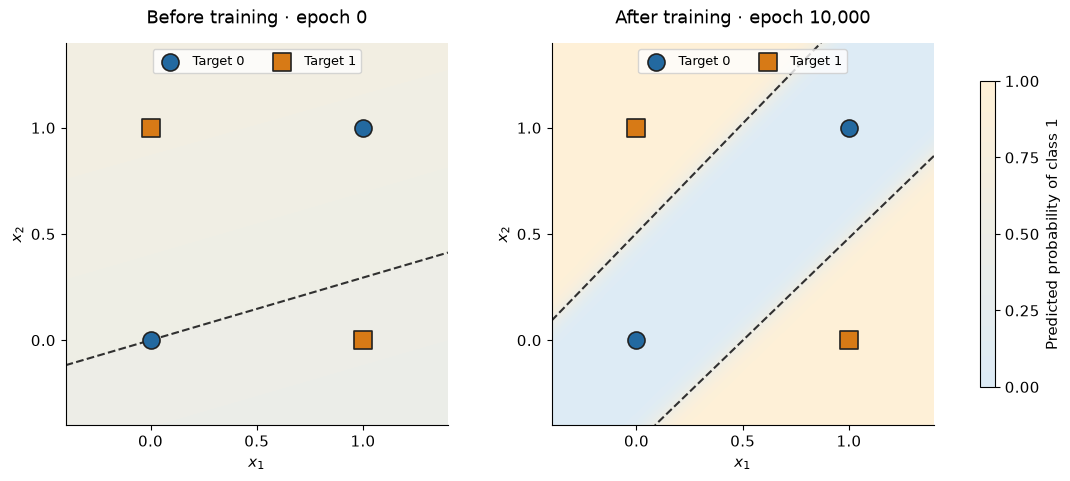

In [6]:
axis_values = np.linspace(-0.4, 1.4, 220)
grid_x, grid_y = np.meshgrid(axis_values, axis_values)
grid_inputs = np.column_stack([grid_x.ravel(), grid_y.ravel()])

def draw_region(ax, model, title):
    probabilities = forward(grid_inputs, model)[0].reshape(grid_x.shape)
    surface = ax.contourf(grid_x, grid_y, probabilities,
                          levels=np.linspace(0, 1, 21), cmap=PROB_CMAP, vmin=0, vmax=1)
    if probabilities.min() < 0.5 < probabilities.max():
        ax.contour(grid_x, grid_y, probabilities, levels=[0.5],
                   colors="#303030", linestyles="--", linewidths=1.5)
    draw_points(ax)
    ax.set_title(title, pad=14)
    return surface

fig, axes = plt.subplots(1, 2, figsize=(11, 4.7), layout="constrained")
draw_region(axes[0], initial_params, "Before training · epoch 0")
surface = draw_region(axes[1], params, f"After training · epoch {EPOCHS:,}")
fig.colorbar(surface, ax=axes, label="Predicted probability of class 1", shrink=0.8,
             ticks=[0, 0.25, 0.5, 0.75, 1])
plt.show()

## Checks
### 6. Final prediction table
Classify as 1 when the probability is at least 0.5. With the supplied seed and training settings, all four truth-table entries should be correct. Different seeds or too few epochs can produce a poor solution; optimization is not guaranteed to succeed on every run.

In [7]:
final_p, (_, final_logits) = forward(X, params)
final_classes = (final_p >= 0.5).astype(int)
rows = ["| x₁ | x₂ | Target | P(class 1) | Predicted | Correct |",
        "|---:|---:|---:|---:|---:|:---:|"]
for inputs, target, probability, prediction in zip(X, y[:, 0], final_p[:, 0], final_classes[:, 0]):
    rows.append(f"| {inputs[0]:.0f} | {inputs[1]:.0f} | {target:.0f} | {probability:.6f} | {prediction} | {'Yes' if prediction == target else 'No'} |")
display(Markdown("\n".join(rows)))
assert np.isfinite(loss_history).all()
assert loss_history[-1] < loss_history[0], "Loss did not improve; review training settings."
assert np.array_equal(final_classes, y.astype(int)), "Not all points learned; try more epochs or another seed."
display(Markdown(f"**Result:** {np.mean(final_classes == y):.0%} training accuracy; "
                 f"BCE decreased from **{loss_history[0]:.6f}** to **{loss_history[-1]:.6f}**."))

| x₁ | x₂ | Target | P(class 1) | Predicted | Correct |
|---:|---:|---:|---:|---:|:---:|
| 0 | 0 | 0 | 0.002610 | 0 | Yes |
| 0 | 1 | 1 | 0.995378 | 1 | Yes |
| 1 | 0 | 1 | 0.995339 | 1 | Yes |
| 1 | 1 | 0 | 0.002233 | 0 | Yes |

**Result:** 100% training accuracy; BCE decreased from **0.707763** to **0.003538**.

### 7. Optional interactive training replay
Move the slider to inspect stored training snapshots. This **replays** training rather than updating weights live. It needs `ipywidgets` and an active notebook kernel. If widgets are unavailable, the static plots above remain the complete demonstration.

In [8]:
try:
    import ipywidgets as widgets
except ImportError:
    print("Optional replay skipped. Install ipywidgets and rerun this cell to enable it.")
else:
    def show_snapshot(snapshot_index):
        epoch, model = snapshots[snapshot_index]
        fig, ax = plt.subplots(figsize=(6.5, 5), layout="constrained")
        surface = draw_region(ax, model, f"Epoch {epoch:,} · BCE {loss_history[epoch]:.4f}")
        fig.colorbar(surface, ax=ax, label="P(class 1)", ticks=[0, 0.5, 1])
        plt.show()
    replay = widgets.interactive(
        show_snapshot,
        snapshot_index=widgets.IntSlider(value=0, min=0, max=len(snapshots)-1,
                                         description="Snapshot", continuous_update=False))
    display(replay)

Optional replay skipped. Install ipywidgets and rerun this cell to enable it.


## Next Steps
- Change `SEED`, then run all cells. Do different runs learn different decision regions?
- Change `LEARNING_RATE` to 0.01 or 1.0. Compare loss curves and convergence.
- Reduce `EPOCHS` to see why the stopping point matters.
- Explain why removing tanh collapses the two affine layers into a single affine transformation, which cannot separate XOR.

**Teaching takeaway:** forward propagation makes predictions, BCE measures error, backpropagation computes derivatives, and gradient descent changes parameters. The nonlinear hidden layer supplies the representation needed to classify XOR.